<a href="https://colab.research.google.com/github/marcorexo/MavenAnalytics/blob/main/Bank_Customer_Data_Prep2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

# SUMMARY
- Load Data: Two Excel sheets, 'Customer_Info' and 'Account_Info', were loaded into separate pandas DataFrames (df_churn_cust_info and df_churn_account_info).

- Merge DataFrames: The two DataFrames were merged into a single DataFrame called churn_df using 'CustomerId' as the key.

- Handle Duplicates and Rename Columns: Duplicate rows were removed, the Tenure_y column (from Account_Info) was dropped, and Tenure_x (from Customer_Info) was renamed to Tenure.

- Convert Data Types: The 'EstimatedSalary' and 'Balance' columns were cleaned by removing the '€' symbol and converting their data types to float.

- Handle Missing Values: Missing values in the 'Surname' column were filled with 'MISSING', and missing values in the 'Age' column were filled with the median age.

- Correct Nonsensical Values: A large negative value (-999999.0) in the 'EstimatedSalary' column was replaced with the median estimated salary.

- Standardize 'Geography' Column: Inconsistent values ('FRA', 'France', 'French') in the 'Geography' column were standardized to 'France'.

#Clean the data


####Because the excel file has **two** sheets I will need to import both when using Python

In [36]:
df_churn_cust_info = pd.read_excel('/content/drive/MyDrive/Maven Analytics/machine-learning-2-classification_course_resources/Bank+Customer+Churn/Bank_Churn_Messy.xlsx', sheet_name="Customer_Info")
df_churn_cust_info.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


####Read in the second sheet
###### Variable of interest is 'Exited'

In [37]:
df_churn_account_info = pd.read_excel('/content/drive/MyDrive/Maven Analytics/machine-learning-2-classification_course_resources/Bank+Customer+Churn/Bank_Churn_Messy.xlsx', sheet_name="Account_Info")
df_churn_account_info.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


# Join both sheets and remove duplicates

#####Tenure is found twice in the columns and there are some row duplicates - sort these out in a bit

In [38]:
churn_df = df_churn_cust_info.merge(df_churn_account_info, how='left', on='CustomerId')
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [39]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


#####Drop Tenure_y and rename Tenure_x to Tenure

In [ ]:
churn_df = churn_df.drop(columns='Tenure_y', axis=1).rename({'Tenure_x':'Tenure'}, axis=1).drop_duplicates()
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


In [ ]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


#**Clean the data**

####1. Some values are objects when they should be float e.g. EstimatedSalary

In [ ]:
churn_df['EstimatedSalary'] = churn_df['EstimatedSalary'].str.replace('€','').astype(float)
churn_df['Balance'] = churn_df['Balance'].str.replace('€','').astype(float)

In [ ]:
churn_df.info()
#now thw EstimatedSalary and Balance are float types

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.1+ MB


####Check for missing values
####Both Age and Surname have missing values, so we could put **'MISSING'** where Surname is NaN and the **median** for the Age column

In [ ]:
churn_df[churn_df.isna().any(axis=1) == True]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,NaN,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,NaN,674,Spain,Male,NaN,6,-999999.0,120193.42,1,No,No,0
9390,15756954,NaN,538,France,Female,NaN,2,-999999.0,0.00,1,Yes,Yes,0


In [ ]:
churn_df = churn_df.fillna({'Surname':'MISSING', 'Age':churn_df['Age'].median()})
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.1+ MB


In [ ]:
churn_df.iloc[[28,121,9389]]
#Check whether this worked

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,MISSING,574,Germany,Female,37.0,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,MISSING,674,Spain,Male,37.0,6,-999999.0,120193.42,1,No,No,0
9390,15756954,MISSING,538,France,Female,37.0,2,-999999.0,0.00,1,Yes,Yes,0


####Are there nonsensical values?

In [ ]:
churn_df.describe()
#Estimated salary has a large negative value: -999999.000000

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,99762.195289,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,60583.863580,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [ ]:
#replace the large negative value with the median of EstimatedSalary
churn_df['EstimatedSalary'].replace(-999999.000000, churn_df['EstimatedSalary'].median(), inplace=True)

/tmp/ipykernel_390/1653056417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_df['EstimatedSalary'].replace(-999999.000000, churn_df['EstimatedSalary'].median(), inplace=True)


In [ ]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


####Geography column has some inconsistent values - change this so that we use the full country name

- France	1741
- French	1655
- FRA	1618


In [ ]:
churn_df['Geography'].value_counts()

,count
Geography,
Germany,2509
Spain,2477
France,1741
French,1655
FRA,1618


In [ ]:
#replace 'FRA', 'France', 'French' in the Geography column with France, otherwise leave it as the current value
churn_df['Geography'] = np.where(churn_df['Geography'].isin(['FRA', 'France', 'French']), 'France', churn_df['Geography'])


In [ ]:
churn_df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


#Code Summary

In [25]:
import pandas as pd
import numpy as np

churn_df = (
    pd.read_excel('/content/drive/MyDrive/Maven Analytics/machine-learning-2-classification_course_resources/Bank+Customer+Churn/Bank_Churn_Messy.xlsx')
    .merge(
        pd.read_excel('/content/drive/MyDrive/Maven Analytics/machine-learning-2-classification_course_resources/Bank+Customer+Churn/Bank_Churn_Messy.xlsx', sheet_name=1),
        how="left",
        on="CustomerId"
    )
    .drop_duplicates()
    .drop("Tenure_y", axis=1)
    .rename({"Tenure_x": "Tenure"}, axis=1)
    .assign(
        EstimatedSalary=lambda x: x["EstimatedSalary"].str.replace("€", "").astype("float"),
        Balance=lambda x: x["Balance"].str.replace("€", "").astype("float"),
        Geography=lambda x: np.where(
            x["Geography"].isin(["France", "French", "FRA"]),
            "France",
            x["Geography"]
        )
    )
    .assign(
        EstimatedSalary=lambda x: x["EstimatedSalary"].replace(-999999, x["EstimatedSalary"].median())
    )
)

churn_df = churn_df.fillna(value={"Surname": "MISSING", "Age": churn_df["Age"].median()})

churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


#Explore the Data

<Axes: xlabel='Exited'>

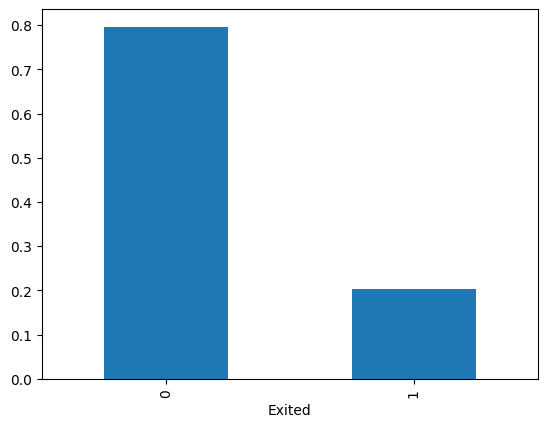

In [ ]:
churn_df['Exited'].value_counts(normalize=True).plot(kind='bar')

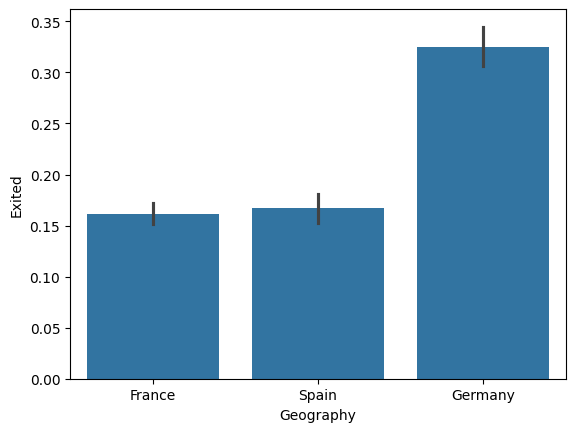

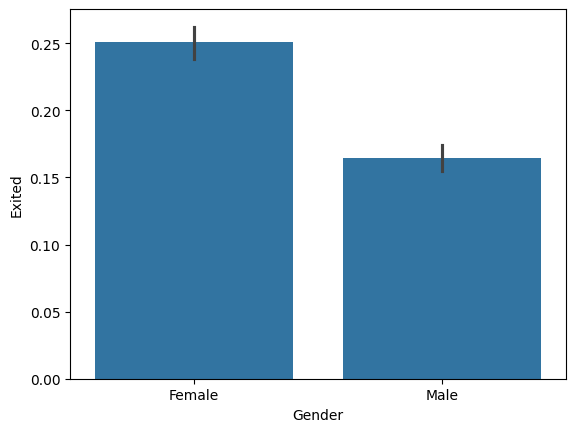

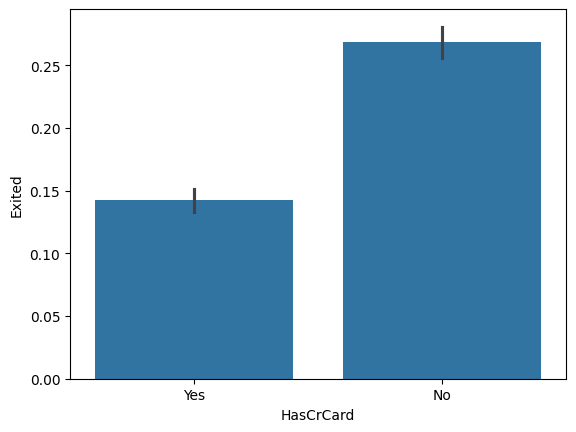

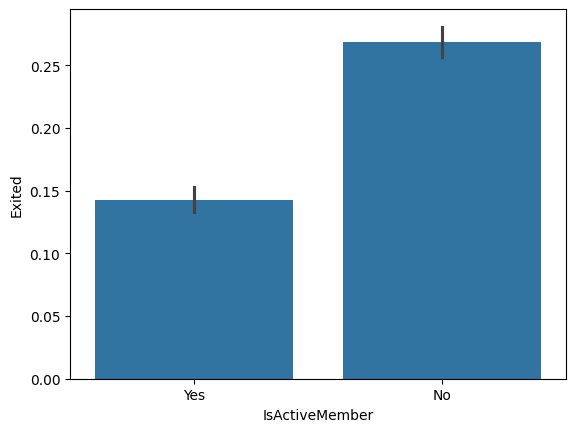

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Explore catagorical variables
for col in churn_df.drop("Surname", axis=1).select_dtypes("object"):
  sns.barplot(x=col, y='Exited', data=churn_df)
  plt.show()


####Greater churn with Germany, customers that don't have a credit card, customers that are not active member, and customer that are female

The box plots revealed that Age, Tenure, and Balance show more distinct differences between customers who churned and those who did not, suggesting these are more influential factors. Conversely, CreditScore, EstimatedSalary, and NumOfProducts exhibited less pronounced variations, indicating they might be weaker indicators of churn.

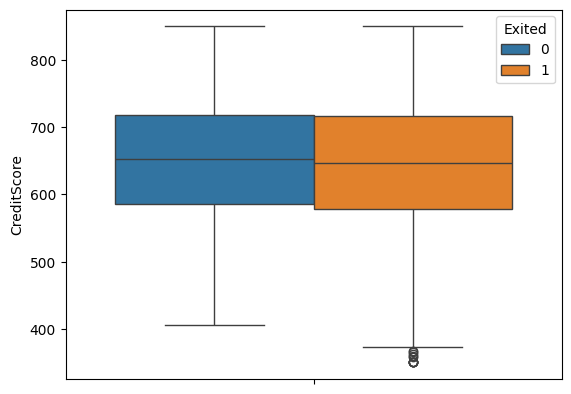

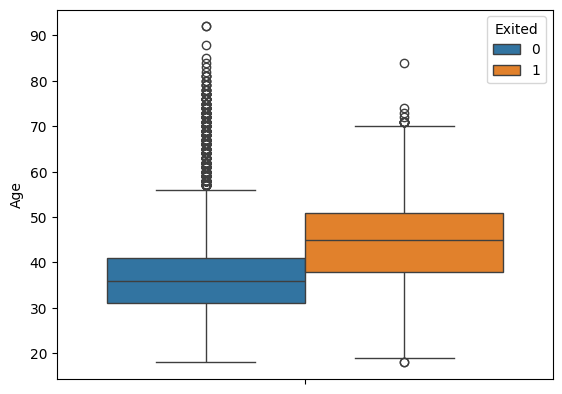

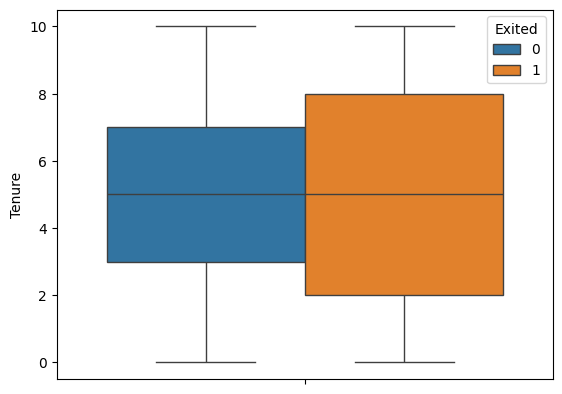

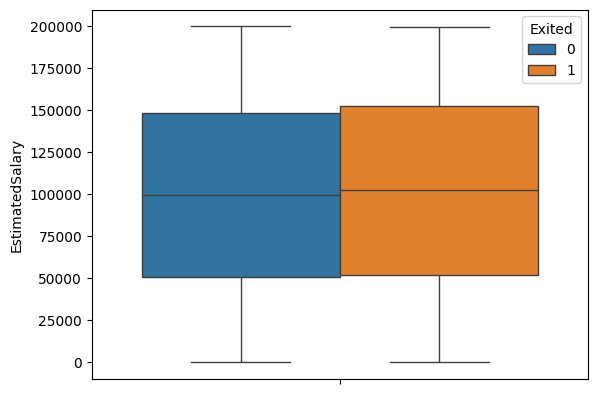

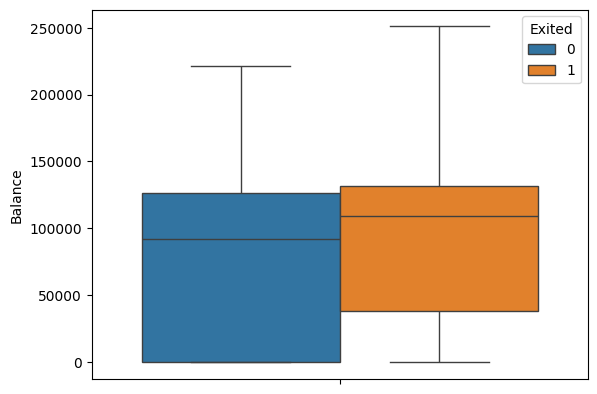

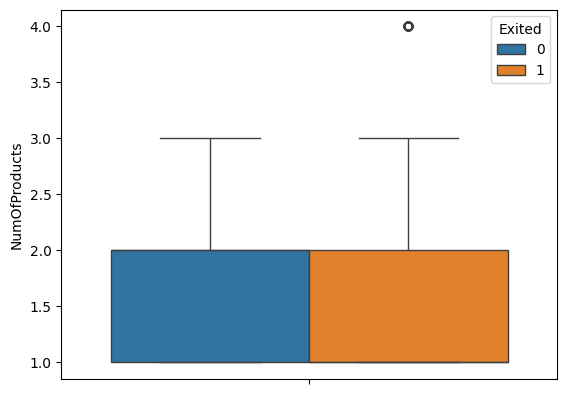

In [ ]:
#Explore numeric variables
for col in churn_df.drop(["CustomerId", "Exited"], axis=1).select_dtypes("number"):
  sns.boxplot(data=churn_df, y=col, hue='Exited')
  plt.show()

# Not much difference in the credit score variable, estimated salary or number of products

From the histplots, a key finding is that the distributions for Age, Tenure, and Balance show more distinct differences between customers who exited and those who did not. For example, churned customers tend to be older, have shorter tenure, and often higher balances compared to active customers. In contrast, CreditScore, EstimatedSalary, and NumOfProducts appear to have less pronounced differences in their distributions across the two groups.



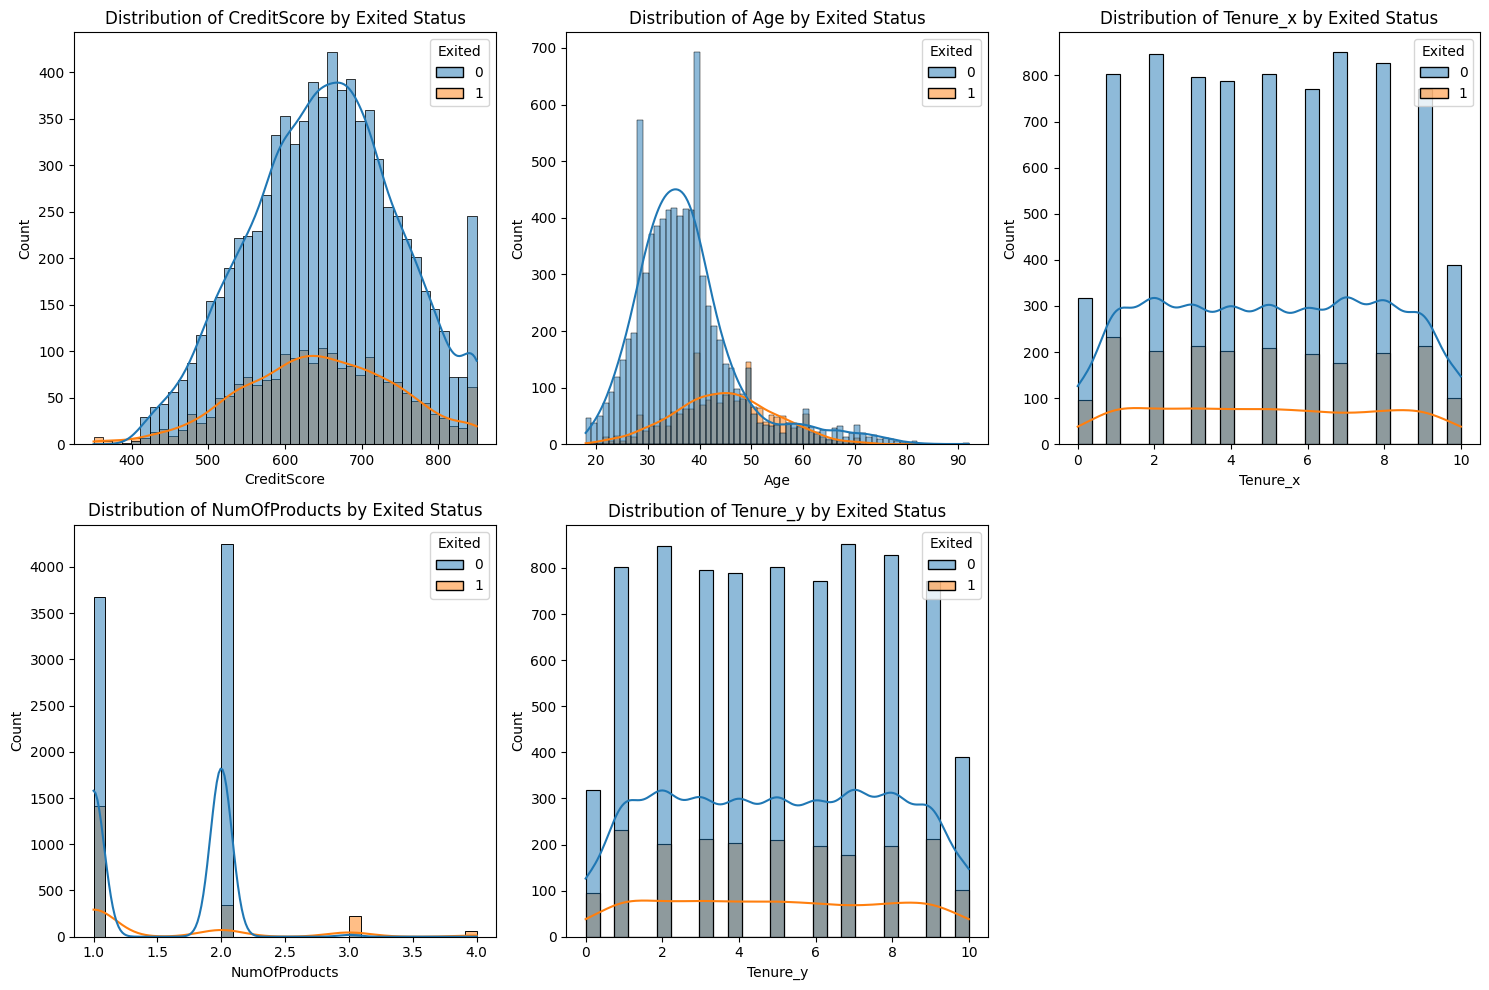

In [40]:
import math

numeric_cols = churn_df.drop(["CustomerId", "Exited"], axis=1).select_dtypes("number").columns
num_plots = len(numeric_cols)
num_cols = 3 # You can adjust the number of columns in the grid
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_cols):
  sns.histplot(data=churn_df, x=col, hue='Exited', kde=True, ax=axes[i])
  axes[i].set_title(f'Distribution of {col} by Exited Status') # Add a title to each subplot

# Hide any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Feature Engineering


In [26]:
modelling_df = churn_df.drop(["CustomerId", "Surname"], axis=1)
modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0
5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


####Create dummy variables for categorical fields

In [28]:
modelling_df = pd.get_dummies(modelling_df, drop_first=True)

In [29]:
modelling_df["Balance_vs_Salary"] = modelling_df["Balance"] / modelling_df["EstimatedSalary"]
modelling_df.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes,Balance_vs_Salary
0,619,42.0,2,101348.88,0.00,1,1,False,False,False,True,True,0.000000
2,608,41.0,1,112542.58,83807.86,1,0,False,True,False,True,True,0.744677
3,502,42.0,8,113931.57,159660.80,3,1,False,False,False,False,False,1.401375
4,699,39.0,1,93826.63,0.00,2,0,False,False,False,False,False,0.000000
5,850,43.0,2,79084.10,125510.82,1,0,False,True,False,True,True,1.587055


The script Balance_vs_Salary < 10 is used to filter out extreme outliers in the Balance_vs_Salary column. Looking at the modelling_df.describe() output, the maximum value for Balance_vs_Salary is 10614.655440, which is significantly higher than the 75th percentile of 1.514022. Such extreme values can compress the visualization, making it difficult to see the distribution and differences for the majority of the data points. By filtering for values less than 10, we aim to get a clearer, more interpretable view of the distribution for most customers.

<Axes: ylabel='Balance_vs_Salary'>

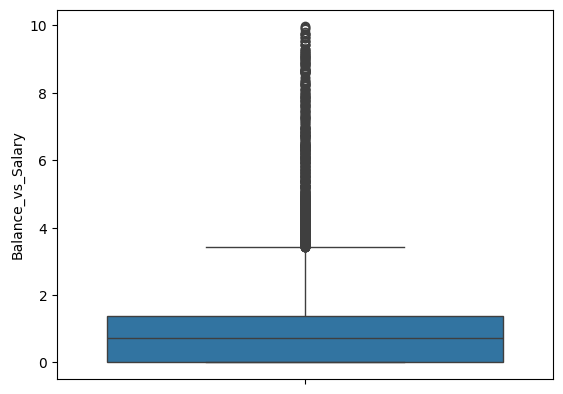

In [34]:
sns.boxplot(data=modelling_df.query("Balance_vs_Salary < 10"), y="Balance_vs_Salary")

In [32]:
modelling_df.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Balance_vs_Salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700,3.878703
std,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769,108.337260
min,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000,0.747002
75%,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000,1.514022
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000,10614.655440


The bar plot of Balance_vs_Salary with Exited as the hue helps us compare the average Balance_vs_Salary ratio between customers who churned and those who did not. A visual inspection of this plot would reveal if there's a significant difference in this ratio between the two groups. For instance, if customers who exited tend to have a higher average Balance_vs_Salary (meaning their balance is proportionally much larger relative to their estimated salary), it could suggest that these customers might be more financially active or have different financial behaviors that lead them to seek alternatives. Conversely, a lower average ratio for churned customers might suggest less financial commitment to the bank.

Key Takeaways from the Whole Analysis:
High-Impact Demographic/Behavioral Factors for Churn:

- Geography: Customers from Germany exhibit a higher churn rate compared to other regions.
Gender: Female customers show a tendency for higher churn.
Credit Card Ownership: Customers without a credit card are more likely to churn.
Active Membership: Inactive members have a significantly higher propensity to churn.
Influential Numerical Predictors:

- Age: Churned customers tend to be older.
Tenure: Customers with shorter tenures (less time with the bank) are more likely to churn.
Balance: Churned customers often have higher account balances.
Less Influential Numerical Predictors:

CreditScore, EstimatedSalary, and NumOfProducts: These variables show less distinct differences between churned and non-churned customers, suggesting they might be weaker indicators of churn compared to Age, Tenure, and Balance.
Engineered Feature Insight (Balance_vs_Salary): This new feature was created to explore the relationship between a customer's balance and salary. The visualization helps to determine if this ratio itself is a significant differentiator between customers who stay and those who leave, providing a more nuanced understanding than just looking at balance or salary in isolation.

<Axes: ylabel='Balance_vs_Salary'>

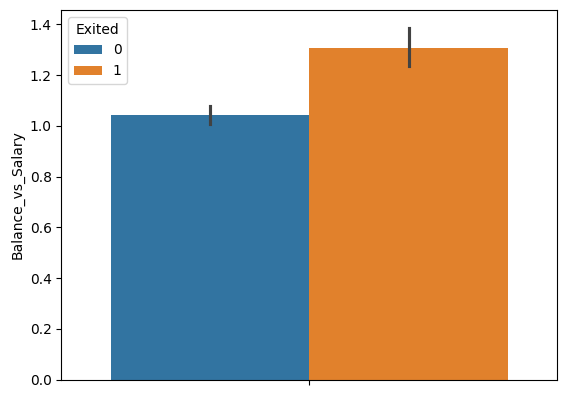

In [35]:
sns.barplot(data=modelling_df.query("Balance_vs_Salary < 10"), y="Balance_vs_Salary", hue="Exited")

##**In summary**, the analysis highlights that customer demographics (like geography, age, and gender) and banking behaviors (such as tenure, active membership, and potentially the balance-to-salary ratio) are crucial in understanding and predicting bank customer churn.